# MVP: Análise de Dados e Boas Práticas - Pós-Graduação PUC-RIO
### Projeto apresentado como atividade final da Sprint Análise de Dados e Boas Práticas

**Autor:** Rogério dos Santos Ferreira  
**Matrícula:** 4052025001195  
**Data:** 04/04/2026

**Dataset:** [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)  
Quais fatores contribuem para a satisfação do cliente em uma companhia aérea?

Link para execução pelo Google Colab:  
<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/blob/master/notebooks/mvp-analise%20de%20dados%20e%20boas%20praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="page-break-after: always;"></div>  

# 1. Definição do Problema

O objetivo deste projeto é a realização da Análise de Dados de dataset acerca da satisfação geral de clientes em relação aos serviços prestados por companhias aéreas, de forma a verificar a existência de possíveis correlações entre os atributos e identificar medidas mitigatórias para o problema de insatisfação. Além da análise citada, os dados serão preparados para o treinamento de modelos de Machine Learning, destinados à classificação dos clientes em graus de satisfação geral ("Satisfeito" ou  "Neutro ou Insatisfeito"), com base em seus atributos sócio-demográficos, no tipo de serviço contratado (classe) e no resultado de questionário de satisfação acerca da percepção de qualidade de detrminados serviços prestados pelas companhias.

## Hipóteses Levantadas

1. A Classe Econômica impacta diretamente na satisfação do cliente? (grau de correlação?)

2. O Tipo da Viagem impacta diretamente na satisfação final do cliente? (grau de correlação?)

3. Qual serviço possui maior influência na satisfação final do cliente?

4. Existem diferenças na percepção de satisfação por gênero ou faixa etária?

## Tipo do Problema

O problema em questão trata-se da construção de um modelo de Machine Learning para a **Classificação Supervisionada** do grau de satisfação geral de clientes de uma companhia aérea com base em um conjunto de informações sócio-demográficas e resultados de consultas de satisfação específicas.

## Seleção de Dados

O Dataset utilizado foi obtido diretamente na plataforma Kaggle, não havendo necessidade de seleção de dados externos. O mesmo encontra-se disponível no endereço [Kaggle - Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction).

## Atributos do Dataset

O Dataset utilizado neste projeto contém **129.880 amostras**, sedo as mesmas compostas de **23 atributos**, os quais são descritos a seguir:

| **ATRIBUTO** | **DESCRIÇÃO** |
| :--- | :--- |
| **Gender**: | Gênero dos passageiros (Feminino, Masculino) |
| **Customer Type**: | O tipo de cliente (Regular, Esporádico) |
| **Age**: | Idade atual dos passageiros |
| **Type of Travel**: | Objetivo do voo (Viagem Pessoal, Viagem de Negócios) |
| **Class**: | Classe da viagem (Executiva, Econômica, Econômica Plus) |
| **Flight distance**: | Distância de voo |
| **Inflight wifi service**: | Nível de satisfação com o serviço de Wi-Fi a bordo (0: Não aplicável; 1-5) |
| **Departure/Arrival time convenient**: | Nível de satisfação com a conveniência do horário de partida/chegada |
| **Ease of Online booking**: | Nível de satisfação com a facilidade da reserva online |
| **Gate location**: | Nível de satisfação com a localização do portão |
| **Food and drink**: | Nível de satisfação com comida e bebida |
| **Online boarding**: | Nível de satisfação com o check-in (embarque) online |
| **Seat comfort**: | Nível de satisfação com o conforto do assento |
| **Inflight entertainment**: | Nível de satisfação com o entretenimento de bordo |
| **On-board service**: | Nível de satisfação com o serviço de bordo |
| **Leg room service**: | Nível de satisfação com o espaço para as pernas |
| **Baggage handling**: | Nível de satisfação com o manuseio de bagagem |
| **Check-in service**: | Nível de satisfação com o serviço de check-in |
| **Inflight service**: | Nível de satisfação com o serviço de bordo (atendimento da tripulação) |
| **Cleanliness**: | Nível de satisfação com a limpeza |
| **Departure Delay in Minutes**: | Minutos de atraso no momento da partida |
| **Arrival Delay in Minutes**: | Minutos de atraso no momento da chegada |
| **Satisfaction**: | Nível de satisfação com a companhia aérea (Satisfeito, Neutro ou Insatisfeit |


<div style="page-break-after: always;"></div>  

# 2. Obtenção dos Dados

## Importação das Bibliotecas e padronizaçãoes

Nesta etapa será consolidada a importação de todas as bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, visando facilitar a identificação de possíveis falhas nos requisitos e a solução de problemas desta natureza. Além disso, será realizada nesta fase a padronização visual das visualizações gráficas empregadas no projeto, buscando uma construção estética mais adequada para facilitra a compreensão das análises realizadas.

In [7]:
# Importação das bibliotecas necessárias para o projeto
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path


# Padronização do estilo dos gráficos para melhor apresentação
sns.set_theme(
    style="darkgrid",
    context="paper",
    palette="deep",
    font_scale=1.0,
)

## Carga de Dados

Tendo em vista que os dados empregados no projeto são oriundo de uma única fonte, já no formato CSV, faz-se necessária apenas a carga do mesmo. Contudo, como os dados encontram-se originalmente separados em dados de treino e teste, foi realizada a combinação do mesmo para a realização dos processos de análise e transformação de forma adequada.

In [8]:
# Definição dos caminhos para os arquivos de dados locais
data_train_path = Path("../dados/originais/Airline Passenger Satisfaction - train.csv")
data_test_path = Path("../dados/originais/Airline Passenger Satisfaction - test.csv")

# Verificação da existência dos arquivos locais e carga dos dados, com fallback para URLs se os arquivos não estiverem disponíveis
# Medida necessária para garantir a carga de dados no Google Colab
if data_train_path.exists() and data_test_path.exists():
    train_data = pd.read_csv(
        "../dados/originais/Airline Passenger Satisfaction - train.csv", index_col=0
    )
    test_data = pd.read_csv(
        "../dados/originais/Airline Passenger Satisfaction - test.csv", index_col=0
    )
else:
    train_data = pd.read_csv(
        "https://raw.githubusercontent.com/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/refs/heads/master/dados/originais/Airline%20Passenger%20Satisfaction%20-%20train.csv",
        index_col=0,
    )
    test_data = pd.read_csv(
        "https://raw.githubusercontent.com/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/refs/heads/master/dados/originais/Airline%20Passenger%20Satisfaction%20-%20test.csv",
        index_col=0,
    )


# Combinação dos dados de treinamento e teste em um único DataFrame para análise exploratória
data = pd.concat([train_data, test_data], ignore_index=True)

<div style="page-break-after: always;"></div>  

## 3. Limpeza e tratamento inicial dos dados

Nesta etapa foram realizados procedimentos iniciais de tratamento de dados visando aprimorar a etapa de análise exploratória. Como parate do processo foi removida a coluna "ID" do datase, tendo em vista não possuir relevância para a nálise dos dados ou para o treinamento do modelo, além disto, por meio do atributo "Age", que originalmente trata-se de uma variável numérica discreta, foi construída a outra variável categórica "Age Group" subdividindo o conjunto em cinco faixas etárias ("0-17", "18-30", "31-50", "51-65", "65+").

In [9]:
# Remoção da coluna ID por não possuir relevância para a análise
data.drop(columns=["id"], inplace=True)

In [10]:
# Criação de nova variável categórica "Age Group" a partir da variável numérica "Age"

# Definição dos bins e labels para categorizar as idades em grupos etários
bins = [0, 18, 31, 51, 66, 100]
labels = [
    "0-17",
    "18-30",
    "31-50",
    "51-65",
    "65+",
]
data["Age Group"] = pd.cut(data["Age"], bins=bins, labels=labels, right=False)

# Reordenação das colunas para melhor organização
# Trazendo as colunas categóricas para o início do dataframe (exceto a variável alvo)
categorical_cols = [
    "Gender",
    "Age Group",
    "Customer Type",
    "Type of Travel",
    "Class",
]
numerical_cols = [col for col in data.columns if col not in categorical_cols]
data = data[categorical_cols + numerical_cols]

In [11]:
# Primeiras linhas do dataset
data.head(3)

,Gender,Age Group,Customer Type,Type of Travel,Class,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,0-17,Loyal Customer,Personal Travel,Eco Plus,13,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,18-30,disloyal Customer,Business travel,Business,25,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,18-30,Loyal Customer,Business travel,Business,26,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


<div style="page-break-after: always;"></div>  

# 3. Análise Exploratória de Dados (EDA)

Nesta etapa de Análise Exploratória de Dados (EDA) sobre o Dataset, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Quantitativo de Amostras e Tipo de Atributos

O Dataset utilizado no projeto, após a etapa de tratamento inicial dos dados, na qual foi criada a variável categórica "Age Group", passou a ser composto de **129.880 amostras** e **24 atributos**. Dos atributos constantes no conjunto de dados 17 são do tipo inteiro (int64), um atributo ("Arrival Delay") é do tipo ponto flutuante (float64) e 6 atributos ("Gender", "Age Group", "Customer Type", "Type of Travel", "Class" e "satisfaction") são categóricos (category/object), como pode ser observado no resumo abaixo:

In [12]:
print(f"Total de instâncias: {len(data)}")
print("\nTipos de dados por coluna:")
print(data.info())

Total de instâncias: 129880

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Gender                             129880 non-null  object  
 1   Age Group                          129880 non-null  category
 2   Customer Type                      129880 non-null  object  
 3   Type of Travel                     129880 non-null  object  
 4   Class                              129880 non-null  object  
 5   Age                                129880 non-null  int64   
 6   Flight Distance                    129880 non-null  int64   
 7   Inflight wifi service              129880 non-null  int64   
 8   Departure/Arrival time convenient  129880 non-null  int64   
 9   Ease of Online booking             129880 non-null  int64   
 10  Gate location                      1

## Distribuição da Variável Alvo

Analisando o gráfico abaixo, podemos observar que a variável alvo "satisfaction" apresenta um pequeno nível de desbalanceamento entre as classes "satisfied" e "neutral ou dissatisfied". Embora não exista um valor fixo universal na literatura técnica para classificar um variável como desbalanceada, a severidade do desbalanceamento é comumente categorizada com base na proporção da classe minoritária em relação ao total da amostra. Para tanto, considera-se um desbalanceamento leve quando a classe minoritária representa entre 20% e 40% do conjunto de dados (HUYEN, 2022, p. 229).

Contudo, com base nos valores observados, a classe minoritária encontra-se acima dos padrões definidos pela literatura técnica para um desbalanceamanto leve, apresentando um percentual de 43% do quantitativo total da variável, podendo desta forma ser descartada a necessidade de intervenção para balanceamento da mesma, sem prejuízo para a construção do modelo de classificação desejado.

satisfaction
neutral or dissatisfied    0.5655
satisfied                  0.4345
Name: proportion, dtype: float64


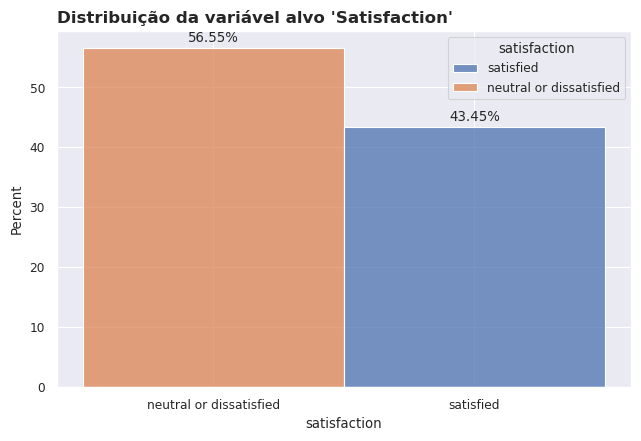

In [13]:
plt.figure(figsize=(6.5, 4.5))

ax = sns.histplot(
    data=data,
    x="satisfaction",
    hue="satisfaction",
    stat="percent",
    multiple="stack",
    hue_order=["satisfied", "neutral or dissatisfied"],
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável alvo 'Satisfaction'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Iteração sobre os containers para inclusão dos rótulos numéricos
for container in ax.containers:
    # Extração das alturas das barras e criação de rótulos condicionais
    # Apenas valores acima de 0 são formatados; os demais recebem string vazia
    labels = [f"{val:.2f}%" if val > 0 else "" for val in container.datavalues]

    # Aplicação dos rótulos filtrados ao container atual
    ax.bar_label(
        container,
        labels=labels,
        padding=2.0,
        label_type="edge",
    )

# Cálculo da proporção entre as classes no Pandas
print(round(data["satisfaction"].value_counts(normalize=True), 4))

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

## Estatísticas Descritivas

As estatísticas descritivas constituem um conjunto de ferramentas fundamentais na análise exploratória de dados, atuando como o primeiro passo para a compreensão de um conjunto de observações. Elas referem-se à utilização de métodos numéricos e gráficos para resumir e descrever as características principais de um conjunto de dados, sem a intenção de fazer inferências para uma população maior (BROWNLEE, 2019, p. 11). Em projetos de machine learning, essas estatísticas são essenciais para entender a estrutura, a distribuição e a qualidade dos dados antes da aplicação de algoritmos preditivos (BROWNLEE, 2016, p. 31).

A aplicação da estatística descritiva permite que o pesquisador obtenha uma visão geral e quantitativa dos atributos presentes no banco de dados. Entre as técnicas mais comuns estão o cálculo das dimensões do conjunto de dados, a revisão dos tipos de atributos e a visualização das primeiras linhas da amostra para identificar padrões iniciais (BROWNLEE, 2016, p. 31). De forma geral, essas medidas buscam simplificar grandes volumes de dados em resumos interpretáveis, facilitando a identificação de anomalias ou necessidades de pré-processamento (GEORGE, 2021, p. xiv).

In [14]:
# Estatísticas descritivas básicas dos Dataset
data.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age Group,129880,5,31-50,55398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,129880,2,Loyal Customer,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,129880,2,Business travel,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,NaN,NaN,NaN,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Inflight wifi service,129880.0,NaN,NaN,NaN,2.728696,1.32934,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,NaN,NaN,NaN,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,129880.0,NaN,NaN,NaN,2.756876,1.40174,0.0,2.0,3.0,4.0,5.0


## Média

A média aritmética constitui uma das medidas de tendência central mais empregadas para descrever o comportamento de um conjunto de dados. Academicamente, a média é definida como o somatório de todos os valores de uma variável dividido pelo número total de observações, servindo como um "valor típico" ou um ponto de equilíbrio estatístico da distribuição (BROWNLEE, 2019, p. 74). Na Análise Exploratória de Dados (EDA), essa métrica é essencial para fornecer uma síntese quantitativa inicial, permitindo que o pesquisador compreenda rapidamente a magnitude dos dados analisados antes de prosseguir para modelagens mais complexas (BROWNLEE, 2016, p. 32).

Para além de uma simples descrição, a média na EDA serve para identificar o centro de massa da distribuição de uma característica (feature), sendo um componente crítico em processos de preparação de dados. Em fluxos de trabalho de machine learning, a média é frequentemente utilizada em técnicas de imputação de dados faltantes, onde valores nulos são substituídos pela média da coluna para preservar a integridade estatística do conjunto (BROWNLEE, 2020, p. 11).

Como podemos observar ...

In [27]:
data.describe().loc["mean"]

Age                                    39.427957
Flight Distance                      1190.316392
Inflight wifi service                   2.728696
Departure/Arrival time convenient       3.057599
Ease of Online booking                  2.756876
Gate location                           2.976925
Food and drink                          3.204774
Online boarding                         3.252633
Seat comfort                            3.441361
Inflight entertainment                  3.358077
On-board service                        3.383023
Leg room service                        3.350878
Baggage handling                        3.632114
Checkin service                         3.306267
Inflight service                        3.642193
Cleanliness                             3.286326
Departure Delay in Minutes             14.713713
Arrival Delay in Minutes               15.091129
Name: mean, dtype: float64

## Desvio Padrão

O desvio padrão é uma medida estatística fundamental utilizada na Análise Exploratória de Dados (EDA) para quantificar a dispersão ou variabilidade de um conjunto de dados em relação à sua média. Uma distribuição com baixo desvio padrão indica que os pontos de dados tendem a estar próximos da média, enquanto um desvio padrão alto sugere que os dados estão espalhados por uma gama mais ampla de valores (GEORGE, 2021, p. 14).

Na etapa de EDA, o desvio padrão serve primordialmente para compreender a "forma" e a confiabilidade dos dados coletados. Ele auxilia o pesquisador a identificar a presença de outliers (valores atípicos), uma vez que dados localizados a muitos desvios padrão de distância da média podem indicar erros de medição ou eventos excepcionais que requerem tratamento especial antes da modelagem (BROWNLEE, 2020a, p. 45). Além disso, o desvio padrão é um componente crítico para a identificação de distribuições Gaussianas, onde aproximadamente 68%, 95% e 99,7% dos dados residem dentro de um, dois e três desvios padrão da média, respectivamente (BROWNLEE, 2019, p. 78).

Observando-se os dados abaixo ...

In [28]:
data.describe().loc["std"]

Age                                   15.119360
Flight Distance                      997.452477
Inflight wifi service                  1.329340
Departure/Arrival time convenient      1.526741
Ease of Online booking                 1.401740
Gate location                          1.278520
Food and drink                         1.329933
Online boarding                        1.350719
Seat comfort                           1.319289
Inflight entertainment                 1.334049
On-board service                       1.287099
Leg room service                       1.316252
Baggage handling                       1.180025
Checkin service                        1.266185
Inflight service                       1.176669
Cleanliness                            1.313682
Departure Delay in Minutes            38.071126
Arrival Delay in Minutes              38.465650
Name: std, dtype: float64

## Histogramas

...

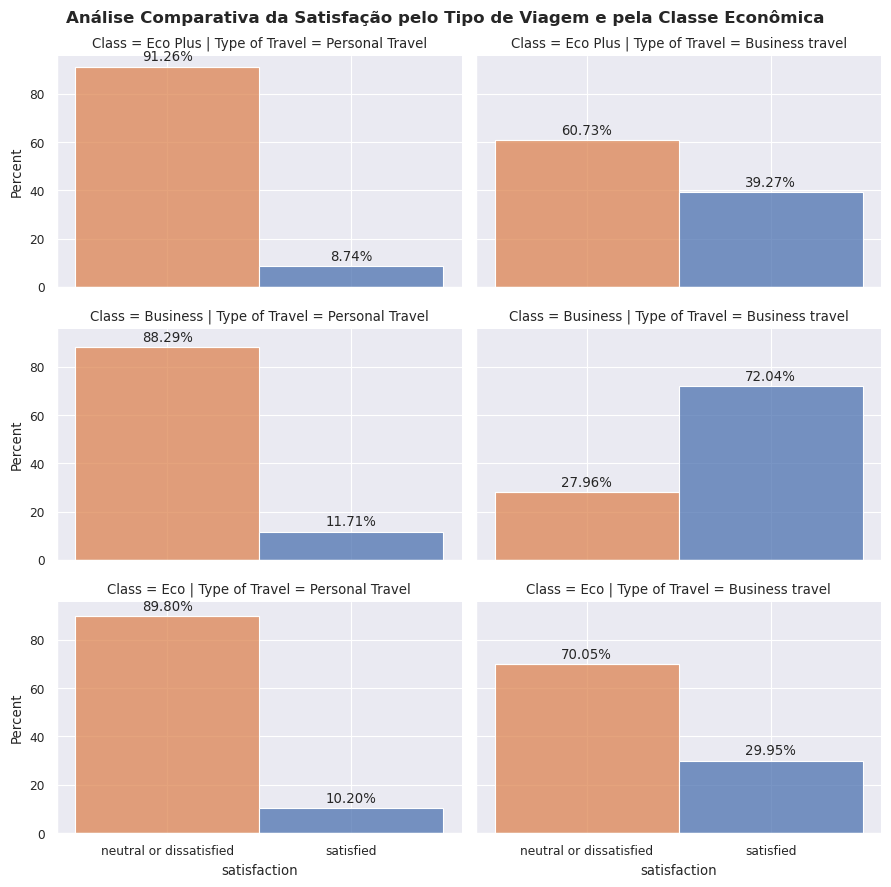

In [ ]:
g = sns.FacetGrid(
    data=data,
    col="Type of Travel",
    row="Class",
    height=3,
    aspect=1.5,
    legend_out=False,
)

g.map_dataframe(
    sns.histplot,
    x="satisfaction",
    hue="satisfaction",
    hue_order=["satisfied", "neutral or dissatisfied"],
    stat="percent",
    multiple="stack",
)

g.figure.suptitle(
    "Análise Comparativa da Satisfação pelo Tipo de Viagem e pela Classe Econômica",
    fontsize=12,
    fontweight="bold",
)

# Iteração sobre os eixos para inclusão dos rótulos numéricos
for ax in g.axes.flatten():
    # Extração dos containers de barras do eixo atual
    for container in ax.containers:
        # Extração das alturas das barras e criação de rótulos condicionais
        labels = [f"{val:.2f}%" if val > 0 else "" for val in container.datavalues]

        # Aplicação dos rótulos filtrados ao container atual
        ax.bar_label(
            container,
            labels=labels,
            padding=2.0,
            label_type="edge",
        )

plt.tight_layout()
plt.show()

# XX. Treinamento do Modelo

Como forma de validação do trabalho realizado foi procedido o treinamento de um modelo de Machine Learning de classificação, destinado à classificar o sentimento geral de satisfação de clientes de uma companhia aérea.

In [64]:
# # Treinamento de modelo de base para evolução posterior

# from autogluon.tabular import TabularPredictor

# # Definição da emente aleatória para reprodutibilidade dos resultados
# RANDOM_SEED = 42

# # Seleção dos modelos empregados
# custom_hyperparameters = {
#     "GBM": [{}],
#     "CAT": [{}],
#     "XGB": [{}],
# }

# # Treinamento do modelo de base utilizando AutoGluon
# predictor = TabularPredictor(
#     label="satisfaction",
#     path="../modelos/",
#     learner_kwargs={"random_state": RANDOM_SEED},
#     verbosity=0,
# ).fit(
#     train_data,
#     hyperparameters=custom_hyperparameters,
#     presets="medium",
#     time_limit=300,
#     verbosity=0,
# )

In [65]:
# # Análise dos modelos empregados e identificação do melhor modelo
# leaderboard = predictor.leaderboard(test_data, silent=True)
# display(leaderboard)

# # Análise de desempenho do melhor modelo
# performance = predictor.evaluate(test_data)

# print("Desempenho do melhor modelo:")
# print(f"Acurácia: {round(performance['accuracy'], 4)}")
# print(f"Precision: {round(performance['precision'], 4)}")
# print(f"F1 Score: {round(performance['f1'], 4)}")
# print(f"Recall: {round(performance['recall'], 4)}")

# XX. Conclusão

XXX ...

# Referências

BROWNLEE, Jason. **Statistical Methods for Machine Learning**: Discover How to Transform Data into Knowledge with Python. v. 1.4. [S.l.]: Machine Learning Mastery, 2019.

BROWNLEE, Jason. **Machine Learning Mastery with Python**: Understand Your Data, Create Accurate Models and Work Projects End-To-End. [S.l.]: Machine Learning Mastery, 2016.

GEORGE, Jordan Goldmeier. **Advancing into Analytics**: From Excel to Python and R. Sebastopol: O'Reilly Media, 2021.

HUYEN, Chip. **Designing Machine Learning Systems**: An Iterative Process for Production-Ready Applications. [S.l.]: O'Reilly Media, 2022.